## Initial baseline model

In [1]:
# Imports
import random
import os
import json
import re
from pathlib import Path
import tqdm
import cv2
from scipy import ndimage


import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

from scripts.preprocess import *
from scripts.pt_model import *
from scripts.layoutlmv3_model import *
from scripts.basic_model import *

from scripts.donut_model import *
from scripts.donut_training_utils import *
from scripts.visualize_util import create_analysis_dashboard, visualize_sample_results

In [2]:
ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")
print(ground_truth_df.columns)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth'],
      dtype='str')


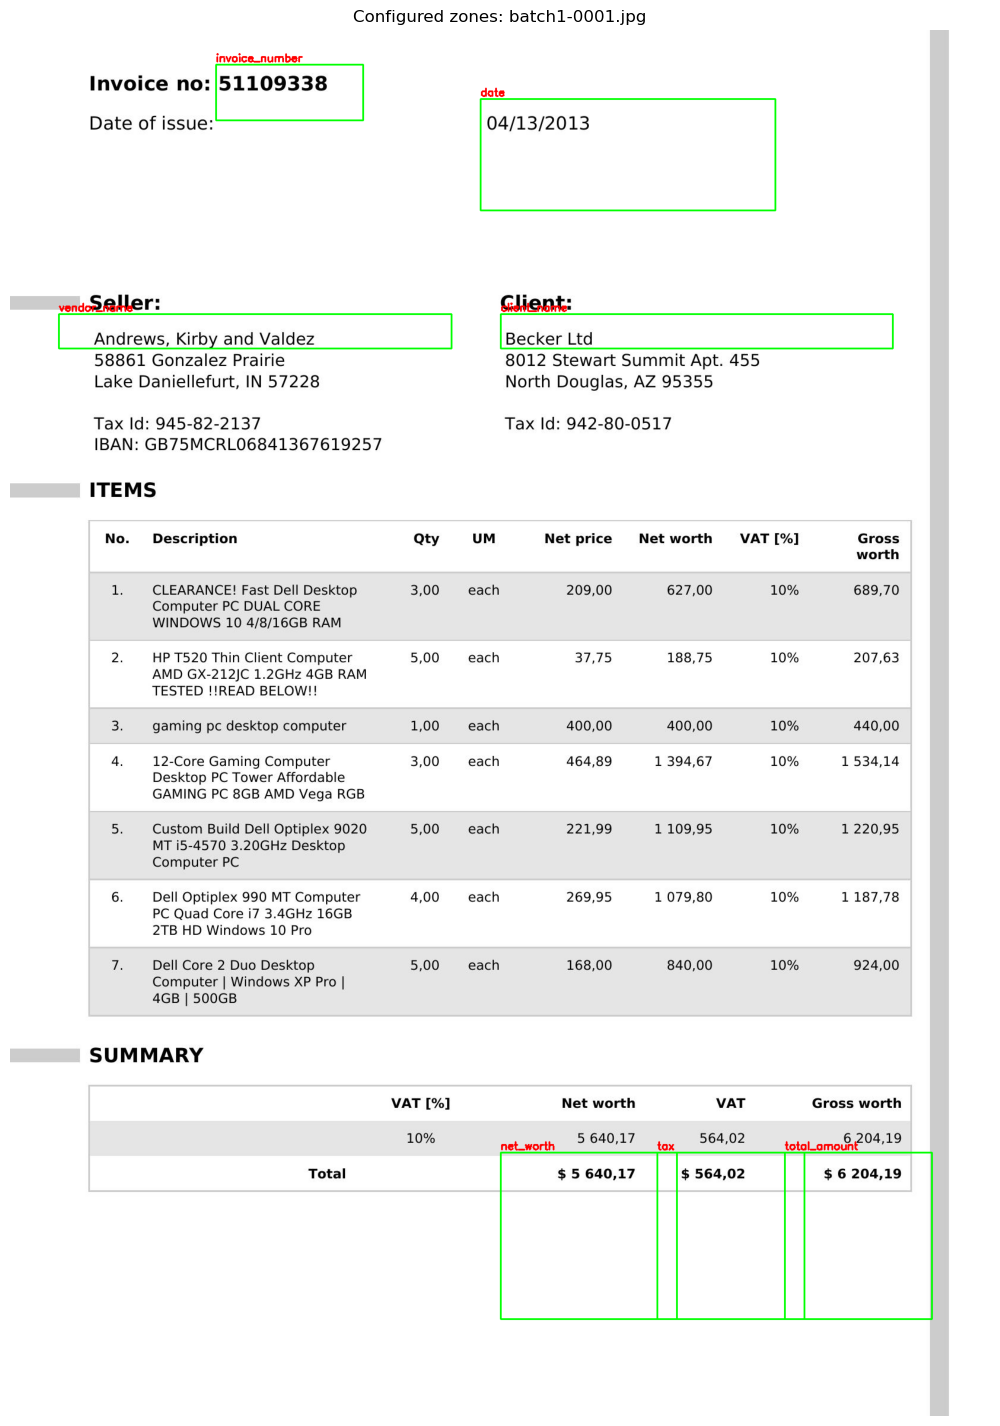

{'invoice_number': '51109338', 'date': '04/13/2013', 'vendor_name': 'Andrews, Kirby and Valdez', 'client_name': 'Becker Ltd', 'net_worth': '5640.17', 'tax': '564.02', 'total_amount': '6204.19'}
{'invoice_number': '51109338', 'date': '04/13/2013', 'vendor_name': 'Andrews, Kirby and Valdez', 'client_name': 'Becker Ltd', 'net_worth': '$5640,17', 'tax': '$564,02', 'total_amount': '$6204,19'}


In [3]:
zones = {
        "default": {
        # Top-left: Invoice number
        "invoice_number": (0.21, 0.025, 0.15, 0.04),

        # Slightly below, shifted right: Date
        "date": (0.48, 0.05, 0.30, 0.08),

        # Middle section
        "vendor_name": (0.05, 0.205, 0.40, 0.025),   # Seller block
        "client_name": (0.50, 0.205, 0.40, 0.025),   # Client block

        # Bottom-right summary section
        "net_worth": (0.50, 0.81, 0.18, 0.12),      # Net worth
        "tax": (0.66, 0.81, 0.15, 0.12),           # VAT
        "total_amount": (0.79, 0.81, 0.15, 0.12),  # Gross worth
        }
        }

# 1) Create the pipeline
basic_pipeline = InvoiceZonalOCRPipeline(template_zones=zones,
    output_dir="../finalproject_data/output_images/basic_ocr"
)

# 2) Tune zones visually on one representative invoice
sample_image = "../finalproject_data/batch_1/batch1_1/batch1-0001.jpg"
basic_pipeline.visualize_zones(sample_image, template_name="default")

# 3) Process one invoice
result = basic_pipeline.process_invoice(sample_image, template_name="default")
print(result["fields"])
print(result["zone_text"])


In [4]:
# 4) Batch process a folder of invoice images
# Define the subfolders you want to process
subfolders = ["batch1_1", "batch1_2", "batch1_3"]
base_path = "../finalproject_data/batch_1/"

# Process each folder and store the resulting dataframes in a list
all_preds = [
    basic_pipeline.process_folder(f"{base_path}{folder}", template_name="default", sample_frac=0.2) 
    for folder in subfolders
]

# Concatenate all dataframes into one
pred_df = pd.concat(all_preds, ignore_index=True)
print(pred_df.head())

Processing 99 images...


Processing invoices: 100%|██████████| 99/99 [03:28<00:00,  2.11s/it]


Processing 100 images...


Processing invoices: 100%|██████████| 100/100 [03:37<00:00,  2.17s/it]


Processing 97 images...


Processing invoices: 100%|██████████| 97/97 [03:23<00:00,  2.10s/it]

         File Name                                         image_path  \
0  batch1-0328.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
1  batch1-0058.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
2  batch1-0013.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
3  batch1-0380.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
4  batch1-0141.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   

   success invoice_number        date              vendor_name  \
0     True       14165207  02/13/2014               Patel-Park   
1     True       80489404  12/21/2013             Gonzalez LLC   
2     True       57986024  10/17/2015              Schmidt LLC   
3     True       13310164  01/16/2020           Montgomery LLC   
4     True       73783721  10/22/2011  Wood, Nichols and Perry   

                  client_name net_worth  tax total_amount  
0  Adkins, Hodges and Hawkins       NaN  NaN          NaN  
1                  Nelson PLC       NaN  NaN

In [5]:
metrics_df = basic_pipeline.evaluate_against_ground_truth(pred_df, ground_truth_df)

         field  accuracy  precision   recall       f1  support
   client_name  0.996390   0.996390 0.996390 0.996390      277
invoice_number  1.000000   1.000000 1.000000 1.000000      277
           tax  0.093863   1.000000 0.093863 0.171617      277
  total_amount  0.086643   0.800000 0.086643 0.156352      277
     net_worth  0.075812   0.913043 0.075812 0.140000      277


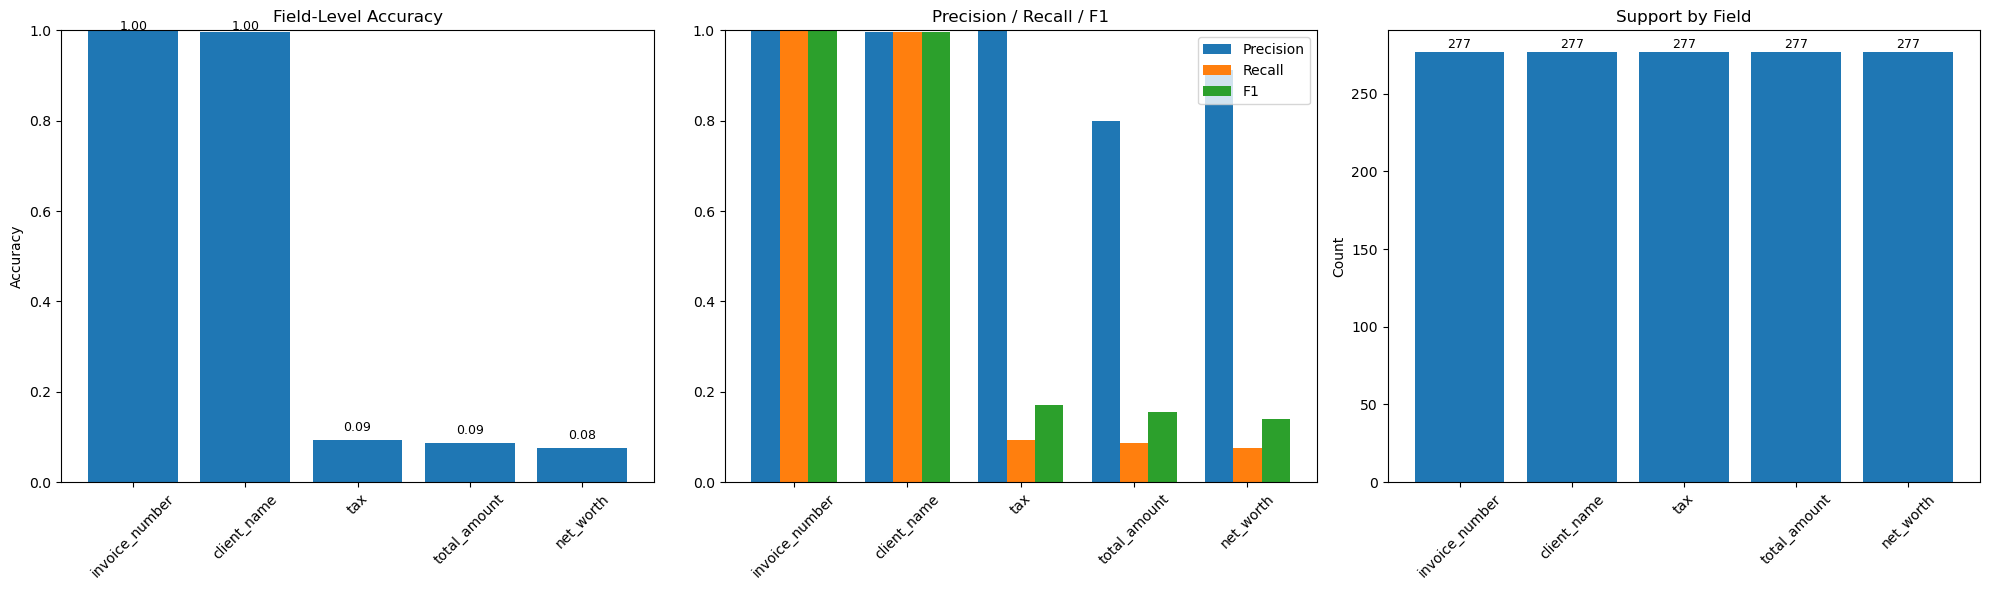

In [6]:
basic_pipeline.visualize_evaluation_metrics(metrics_df)

## CV Model


Processing: batch1_1.csv
Processing 499 images from ../finalproject_data/batch_1/batch1_1.csv
Images location: ../finalproject_data/batch_1/batch1_1


Processing batches: 100%|██████████| 10/10 [00:45<00:00,  4.59s/it]



Processing Complete!
Total images processed: 499
Successful: 499
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_2.csv
Processing 426 images from ../finalproject_data/batch_1/batch1_2.csv
Images location: ../finalproject_data/batch_1/batch1_2


Processing batches: 100%|██████████| 9/9 [00:38<00:00,  4.33s/it]



Processing Complete!
Total images processed: 426
Successful: 426
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_3.csv
Processing 489 images from ../finalproject_data/batch_1/batch1_3.csv
Images location: ../finalproject_data/batch_1/batch1_3


Processing batches: 100%|██████████| 10/10 [00:44<00:00,  4.44s/it]



Processing Complete!
Total images processed: 489
Successful: 489
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

FINAL SUMMARY
Total images across all batches: 1414
Successfully processed: 1414
Failed: 0

Visualizing sample results...


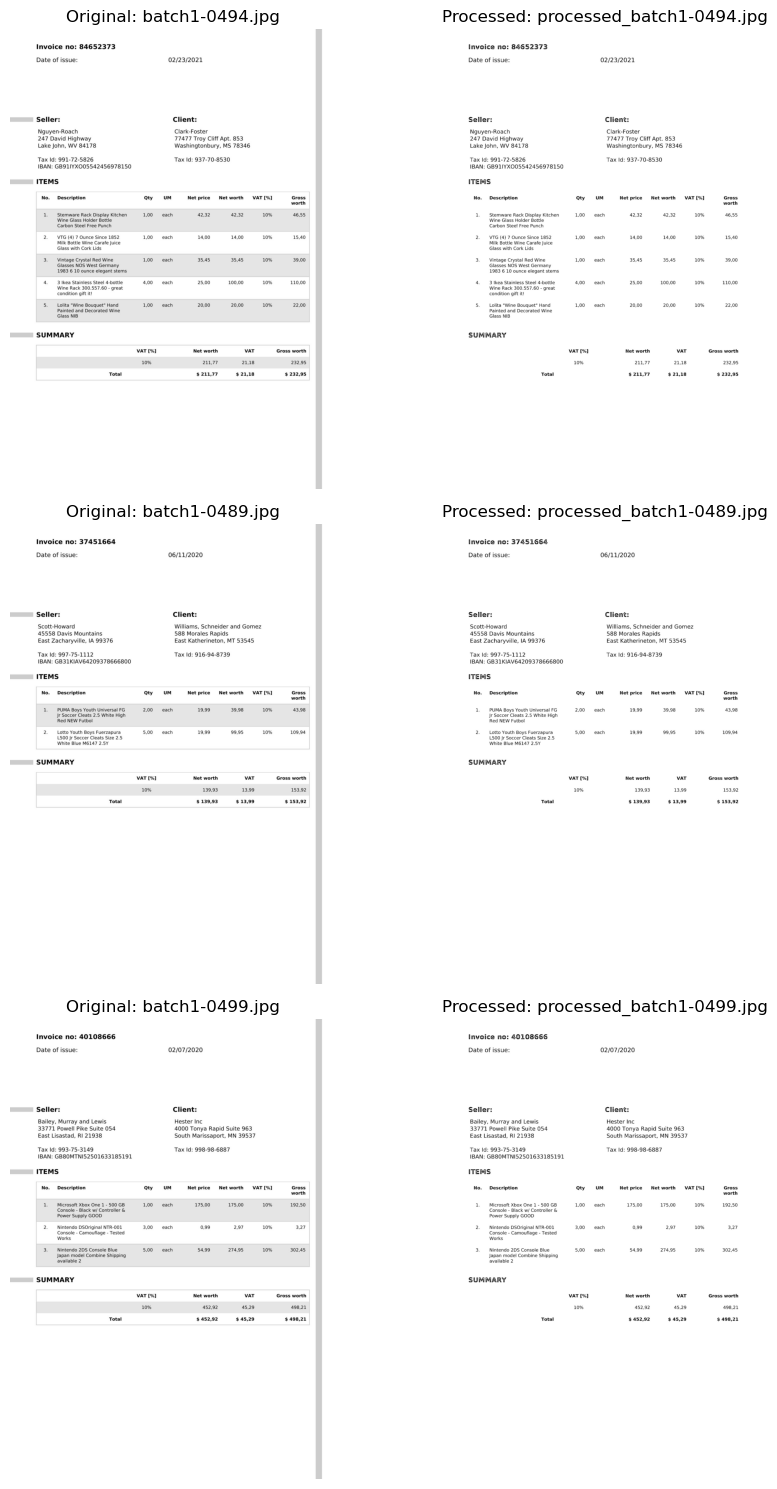

Processed images saved to: ../finalproject_data/processed_images


In [7]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv"
]

# Initialize preprocessor
preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    '../finalproject_data/batch_1/batch1_1',
    '../finalproject_data/batch_1/batch1_2',
    '../finalproject_data/batch_1/batch1_3'
]

# Process all datasets
all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")
    
    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

# Combine all results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")
    
    # Visualize sample results
    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)
    
    print(f"Processed images saved to: {output_image_path}")

In [8]:
# Merge DFs to get processed image file paths
gt_merged_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
print(gt_merged_df.columns)
gt_merged_df.drop(columns=["File Name", "due_date"], inplace=True)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth', 'original_file', 'processed_file', 'original_path',
       'processed_path', 'status'],
      dtype='str')


In [ ]:
# Initialize text detector
ocr_text_detector = PytesseractInvoiceTextDetector(output_dir="../finalproject_data/output_images")

# Process all of the invoices 
summary_df = ocr_text_detector.process_dataset(combined_results, sample_frac=0.1)

Processing 141 sampled images (10.0%)...


Processing OCR batches: 100%|██████████| 15/15 [01:48<00:00,  7.20s/it]


TEXT DETECTION SUMMARY
Total images processed: 141
Successful extractions: 141
Failed extractions: 0
Average words per image: 139.2
Average confidence: 93.7%

Extracted invoice fields:
  invoice_number: 141 images (100.0%)
  invoice_date: 141 images (100.0%)
  seller_name: 141 images (100.0%)
  client_name: 141 images (100.0%)
  tax: 120 images (85.1%)
  net_worth: 112 images (79.4%)
  total_amount: 120 images (85.1%)


In [ ]:
# Produce metrics
metrics_df, overall = ocr_text_detector.evaluate_against_ground_truth(gt_merged_df)

print(metrics_df)
print("\nOverall:", overall)

Prediction rows: 141
Prediction unique keys: 141
Ground truth rows: 1414
Ground truth unique keys: 1413
Key overlap: 141
Prediction rows: 141
Prediction unique keys: 141
Ground truth rows: 141
Ground truth unique keys: 141
Key overlap: 141
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 141              141      140  0.992908   
1    invoice_date                 141              141      141  1.000000   
2     seller_name                 141              141      141  1.000000   
3     client_name                 141              141      141  1.000000   
4       net_worth                 141              112      108  0.765957   
5    total_amount                 141              120      111  0.787234   
6             tax                 141              120      118  0.836879   

   precision    recall        f1  
0   0.992908  0.992908  0.992908  
1   1.000000  1.000000  1.000000  
2   1.000000  1.000000  1.000000  
3  

In [11]:
ocr_text_detector.debug_end_to_end(combined_results, gt_merged_df, n_samples=5)

Debugging 5 invoices

DEBUGGING FILE: processed_batch1-0858.jpg

OCR WORDS (204 words):
Invoice              | conf= 84 | bbox=(273, 155, 260, 51)
no:                  | conf= 96 | bbox=(567, 167, 106, 39)
59506452             | conf= 94 | bbox=(708, 155, 359, 51)
Date                 | conf= 96 | bbox=(273, 293, 138, 44)
of                   | conf= 96 | bbox=(437, 291, 57, 46)
issue:               | conf= 96 | bbox=(517, 291, 166, 46)
11/20/2017           | conf= 96 | bbox=(1613, 291, 340, 52)
Seller:              | conf= 96 | bbox=(271, 891, 234, 70)
Client:              | conf= 93 | bbox=(1657, 895, 236, 50)
Alexander,           | conf= 95 | bbox=(285, 1021, 294, 48)
Schneider            | conf= 95 | bbox=(605, 1021, 275, 42)
and                  | conf= 96 | bbox=(901, 1021, 96, 42)
Russo                | conf= 96 | bbox=(1025, 1023, 156, 40)
Graham-Martinez      | conf= 91 | bbox=(1673, 1021, 479, 42)
189                  | conf= 96 | bbox=(290, 1094, 97, 41)
Pearson             


Invoice Processing Analysis Dashboard

PROCESSING OVERVIEW
Total images processed: 141
Successful extractions: 141 (100.0%)
Failed extractions: 0 (0.0%)

FIELD EXTRACTION SUCCESS RATES
  invoice_number : 100.0%
  invoice_date   : 100.0%
  seller_name    : 100.0%
  client_name    : 100.0%
  tax            :  85.1%
  net_worth      :  79.4%
  total_amount   :  85.1%


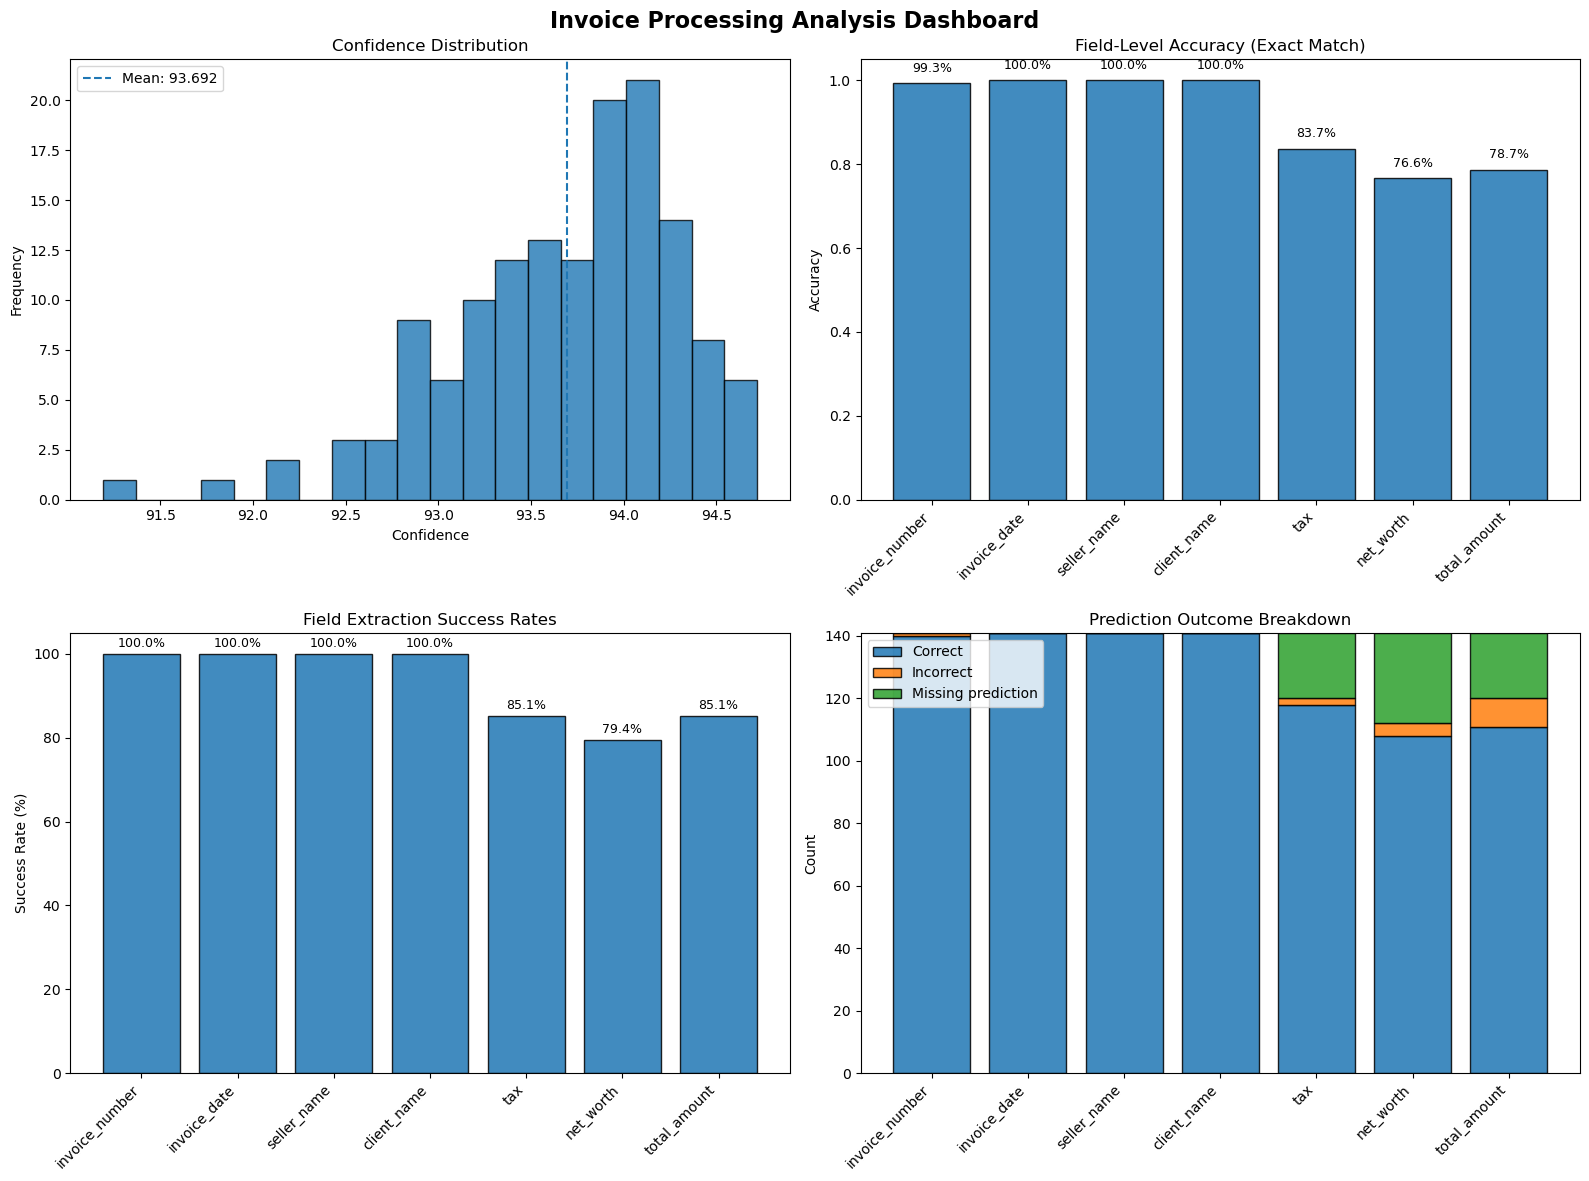


Sample 1: processed_batch1-0858.jpg
Total words detected: 204
Average confidence: 93.417

Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample extracted text (first 10 words):
  Invoice no: 59506452 Date of issue: 11/20/2017 Seller: Client: Alexander,...


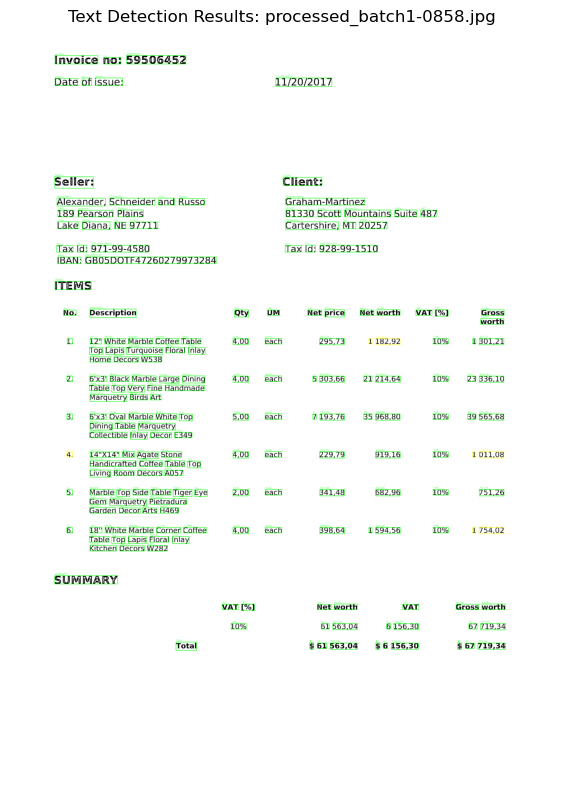


Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample 2: processed_batch1-0935.jpg
Total words detected: 124
Average confidence: 94.435

Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample extracted text (first 10 words):
  Invoice no: 90172850 Date of issue: 09/22/2012 Seller: Client: Johnson,...


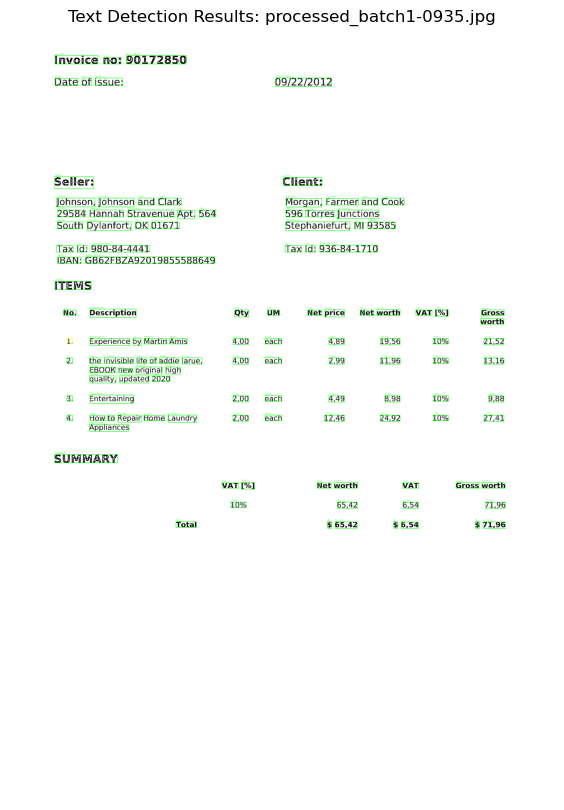


Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample 3: processed_batch1-0412.jpg
Total words detected: 116
Average confidence: 93.129

Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86

Sample extracted text (first 10 words):
  Invoice no: 60866416 Date of issue: 02/17/2021 Seller: Client: Parker,...


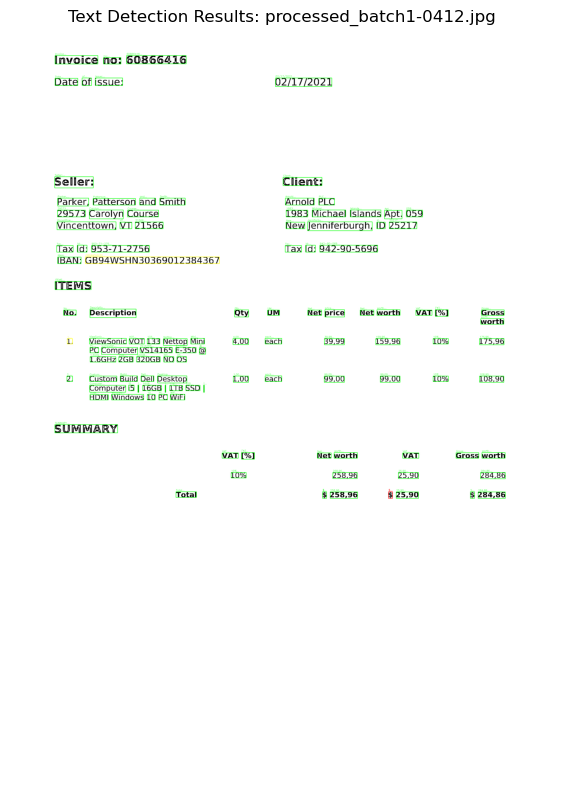


Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86


In [12]:
dashboard_stats = create_analysis_dashboard(
    ocr_text_detector.full_results,
    metrics_df=metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"]
)

visualize_sample_results(
    ocr_text_detector.full_results,
    visualize_text_fn=ocr_text_detector.visualize_text_extraction,
    n_samples=3
)

## LayoutLMv3 model (weak supervision)

In [13]:
# Reuse earlier `combined_results` if present; otherwise load from disk
if "combined_results" not in globals():
    combined_results = pd.read_csv("../finalproject_data/combined_results.csv")
if "ground_truth_df" not in globals():
    ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")

# Merge to align GT with processed image paths
if "gt_merged_df" not in globals():
    gt_merged_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
    gt_merged_df = gt_merged_df.drop(columns=["File Name", "due_date"], errors="ignore")

layoutlm_data_dir = "../finalproject_data/layoutlmv3_data"
builder = LayoutLMv3InvoiceDatasetBuilder(output_dir=layoutlm_data_dir)

examples = builder.build_examples(
    gt_merged_df,
    image_col="processed_path",
    key_col="processed_file",
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    max_examples=500,
)

jsonl_path = builder.save_jsonl(examples)
print(f"Built {len(examples)} weak-labeled examples")
print(f"Saved: {jsonl_path}")

Built 500 weak-labeled examples
Saved: ../finalproject_data/layoutlmv3_data/layoutlmv3_weak_labels.jsonl


In [14]:
# Train/val split
train_examples, val_examples = train_test_split(examples, test_size=0.2, random_state=42)

layoutlm_output_dir = "../finalproject_data/layoutlmv3_finetuned_model"

layoutlm_detector = LayoutLMv3InvoiceTokenClassifier()
layoutlm_detector.train(
    train_examples=train_examples,
    eval_examples=val_examples,
    output_dir=layoutlm_output_dir,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
)

print(f"Saved LayoutLMv3 model to: {layoutlm_output_dir}")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.dense.bias      | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Seqeval F1
50,0.387042,0.108117,0.761302
100,0.071297,0.028381,0.947615
150,0.025351,0.016273,0.961058
200,0.018672,0.010143,0.981189
250,0.011060,0.008403,0.986384
300,0.012421,0.008040,0.981301
350,0.006349,0.008377,0.983533
400,0.009922,0.007300,0.985007
450,0.006924,0.005499,0.987915
500,0.004871,0.004955,0.990189


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved LayoutLMv3 model to: ../finalproject_data/layoutlmv3_finetuned_model


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Prediction rows: 141
Prediction unique keys: 141
Ground truth rows: 1414
Ground truth unique keys: 1413
Key overlap: 141
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 141              141      140  0.992908   
1    invoice_date                 141              141      141  1.000000   
2     seller_name                 141              130      130  0.921986   
3     client_name                 141              121      121  0.858156   
4             tax                 141              138      125  0.886525   
5       net_worth                 141              122       75  0.531915   
6    total_amount                 141              122       78  0.553191   

   precision    recall        f1  
0   0.992908  0.992908  0.992908  
1   1.000000  1.000000  1.000000  
2   1.000000  0.921986  0.959410  
3   1.000000  0.858156  0.923664  
4   0.905797  0.886525  0.896057  
5   0.614754  0.531915  0.570342  
6   0.639344  0.5

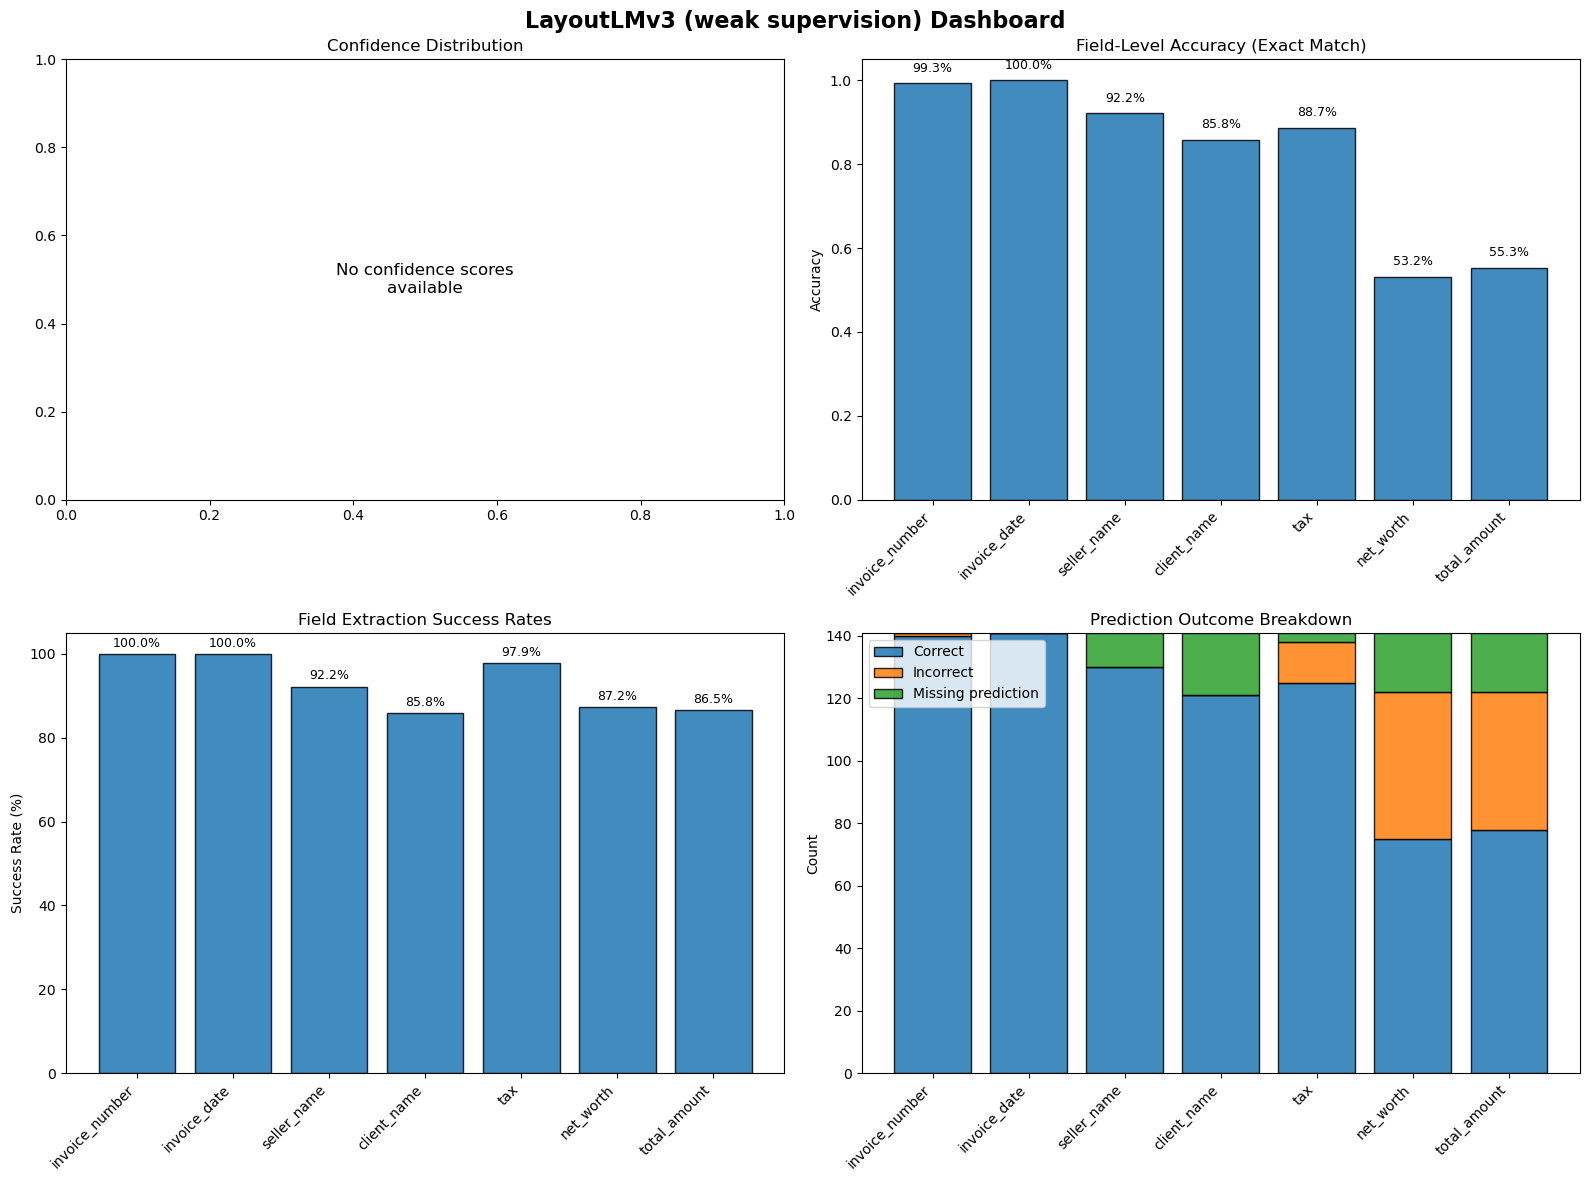

In [15]:
# Inference + evaluation (matches Pytesseract evaluator)
layoutlm_detector.reload_model(layoutlm_output_dir)

layoutlm_pred_df = layoutlm_detector.run_inference(gt_merged_df, sample_frac=0.1)

layoutlm_metrics_df, layoutlm_overall = layoutlm_detector.evaluate_against_ground_truth(
    ground_truth_df=gt_merged_df,
    pred_df=layoutlm_pred_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    merge_key="processed_file",
)

print(layoutlm_metrics_df)
print("\nOverall:", layoutlm_overall)

_ = create_analysis_dashboard(
    layoutlm_detector.full_results,
    metrics_df=layoutlm_metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    title="LayoutLMv3 (weak supervision) Dashboard",
)
